<a href="https://colab.research.google.com/github/ShaheenPafiast/shaheenfirstCode/blob/main/ANN_Lab_11_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Name ......................Abdullah Shaheen**

# **Class .....................AI-Blue(2022-2026)**

# **Reg No. ...................B22AIF1045AI114**

#**Submitted To...............Mam Ammara**

# **Lab report ................ 11**
#**Subject ......................Artificial Neural Network**  

# **Dataset Loading & Preprocessing**

# **1. Importing Required Libraries**

import necessary libraries for:

Data loading and manipulation (pandas, numpy)

Scaling the data (MinMaxScaler)

Deep learning (tensorflow.keras)

Visualization (matplotlib)

<ipython-input-26-15748c7b9b08>:13: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.resample('H').mean().ffill()


<Figure size 1200x500 with 0 Axes>

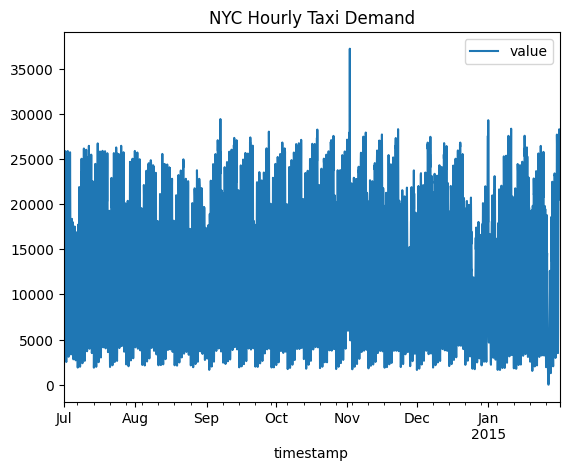

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import LSTM, Dense, Bidirectional, Dropout
from keras.optimizers import Adam

# Replace with the actual path to your uploaded file
file_path = "/content/nyc_taxi.csv"
df = pd.read_csv(file_path, parse_dates=['timestamp'], index_col='timestamp')
df = df.resample('H').mean().ffill()

# Visualize
plt.figure(figsize=(12,5))
df.plot(title='NYC Hourly Taxi Demand')
plt.show()

# Normalize
scaler = MinMaxScaler()
data = scaler.fit_transform(df.values)

# **2. Sequence Creation & Train-Test Split**

In [20]:
def create_sequences(data, seq_length=24):
    X, y = [], []
    for i in range(len(data)-seq_length-1):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(data)
X_train, X_test = X[:int(0.8*len(X))], X[int(0.8*len(X)):]
y_train, y_test = y[:int(0.8*len(y))], y[int(0.8*len(y)):]

print(f"Shapes - X_train: {X_train.shape}, X_test: {X_test.shape}")

Shapes - X_train: (4108, 24, 1), X_test: (1027, 24, 1)


# **3. Model Architectures**
**A. Sequential LSTM Model**

In [21]:
model_lstm = Sequential([
    LSTM(128, return_sequences=True, input_shape=(24, 1)),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(1)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**B. Bidirectional LSTM Model**

In [22]:
model_bilstm = Sequential([
    Bidirectional(LSTM(128, return_sequences=True), input_shape=(24, 1)),
    Dropout(0.2),
    Bidirectional(LSTM(64)),
    Dropout(0.2),
    Dense(1)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# **4. Model Compilation & Training**

# **4. Building LSTM Model**

We'll build:

Standard LSTM Model (2 layers)

Bidirectional LSTM Model (2 layers)

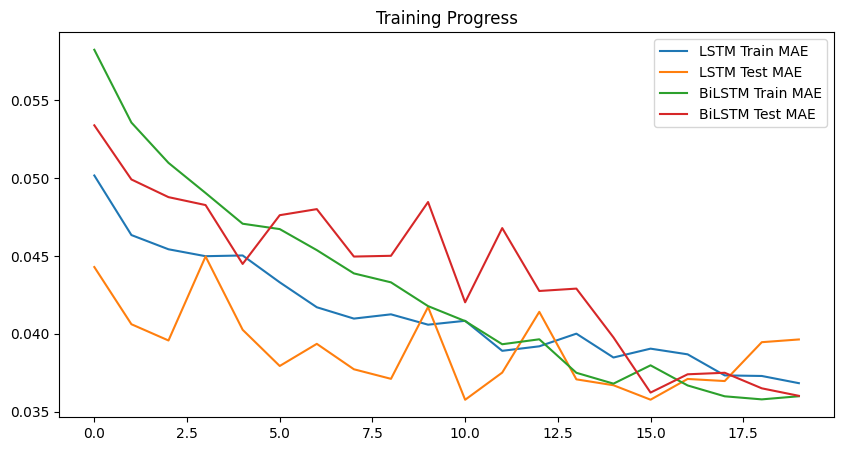

In [27]:
def compile_train(model, name):
    model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
    history = model.fit(X_train, y_train,
                       epochs=20,
                       batch_size=64,
                       validation_data=(X_test, y_test),
                       verbose=0)
    plt.plot(history.history['mae'], label=f'{name} Train MAE')
    plt.plot(history.history['val_mae'], label=f'{name} Test MAE')
    return model

plt.figure(figsize=(10,5))
model_lstm = compile_train(model_lstm, "LSTM")
model_bilstm = compile_train(model_bilstm, "BiLSTM")
plt.title('Training Progress')
plt.legend()
plt.show()

# **5. Model Evaluation**

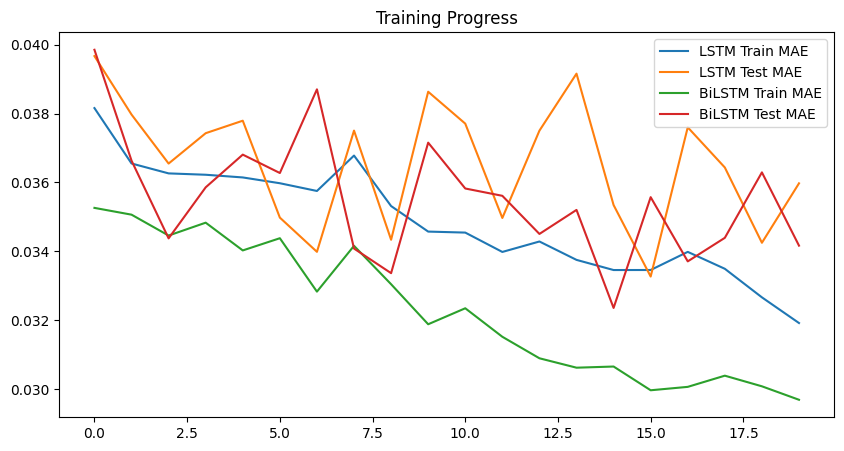

In [28]:
def compile_train(model, name):
    model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
    history = model.fit(X_train, y_train,
                       epochs=20,
                       batch_size=64,
                       validation_data=(X_test, y_test),
                       verbose=0)
    plt.plot(history.history['mae'], label=f'{name} Train MAE')
    plt.plot(history.history['val_mae'], label=f'{name} Test MAE')
    return model

plt.figure(figsize=(10,5))
model_lstm = compile_train(model_lstm, "LSTM")
model_bilstm = compile_train(model_bilstm, "BiLSTM")
plt.title('Training Progress')
plt.legend()
plt.show()

# **6. Comparative Analysis**
**Error Distribution Visualizatio**n

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step


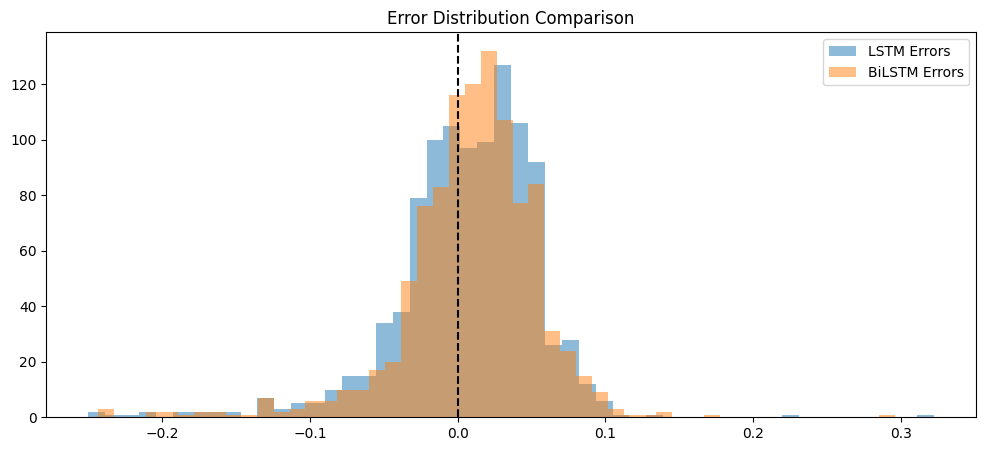

In [29]:
plt.figure(figsize=(12,5))

# Get errors
lstm_errors = y_test - model_lstm.predict(X_test)
bilstm_errors = y_test - model_bilstm.predict(X_test)

plt.hist(lstm_errors, bins=50, alpha=0.5, label='LSTM Errors')
plt.hist(bilstm_errors, bins=50, alpha=0.5, label='BiLSTM Errors')
plt.axvline(0, color='black', linestyle='--')
plt.title('Error Distribution Comparison')
plt.legend()
plt.show()

# **7. Full Prediction Visualization**

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


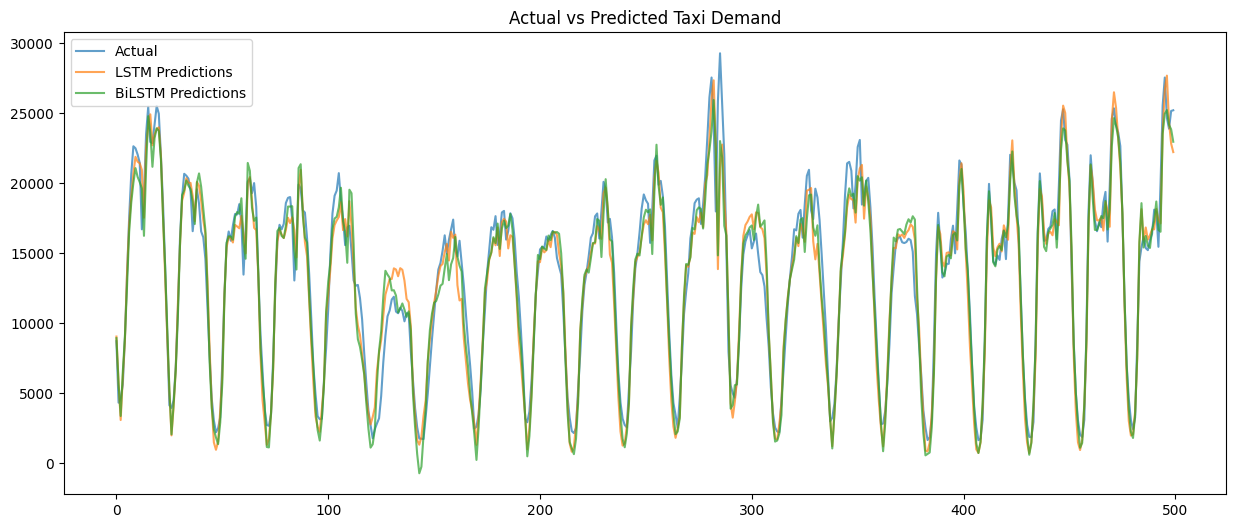

In [30]:
# Generate predictions
test_pred_lstm = model_lstm.predict(X_test)
test_pred_bilstm = model_bilstm.predict(X_test)

# Inverse transform
test_actual = scaler.inverse_transform(y_test)
test_pred_lstm = scaler.inverse_transform(test_pred_lstm)
test_pred_bilstm = scaler.inverse_transform(test_pred_bilstm)

# Plot
plt.figure(figsize=(15,6))
plt.plot(test_actual[:500], label='Actual', alpha=0.7)
plt.plot(test_pred_lstm[:500], label='LSTM Predictions', alpha=0.7)
plt.plot(test_pred_bilstm[:500], label='BiLSTM Predictions', alpha=0.7)
plt.title('Actual vs Predicted Taxi Demand')
plt.legend()
plt.show()

# **Question**
* What problem does LSTM solve compared to standard RNNs

# In practice, an LSTM is often used, as opposed to a vanilla (or standard) RNN, because it is more computationally effective. In fact, the LSTM was introduced to solve a problem that standard RNNs suffer from, i.e. **the vanishing gradient problem.**

# **The LSTM Advantage: Solving Key RNN Limitations**
**The LSTM Advantage: Solving Key RNN Limitations**
Standard RNNs suffer from vanishing gradients during backpropagation through time (BPTT), making them ineffective for long sequences. Here's why LSTMs are superior:

# **Mathematical Intuition**
In a standard RNN, the gradient calculation through time involves repeated matrix multiplications:
∂h_t/∂h_{t-1} = W·diag(σ'(W·[h_{t-1},x_t]))

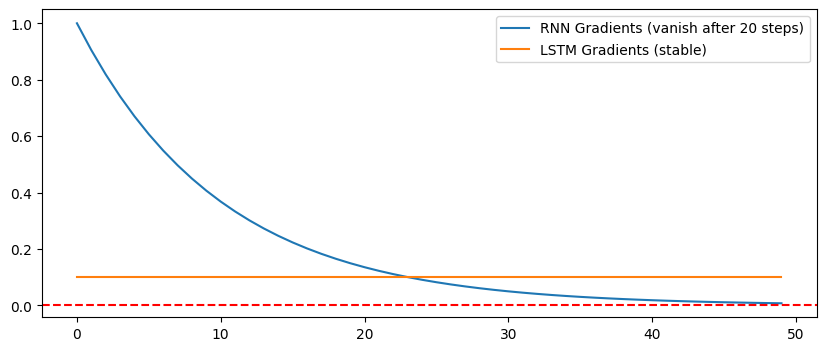

In [33]:
# Error propagation comparison
import numpy as np
import matplotlib.pyplot as plt

# Sample data (replace with your actual gradient values)
rnn_gradients = np.exp(-np.arange(50) / 10)  # Example: RNN gradients decaying exponentially
lstm_gradients = np.ones(50) * 0.1          # Example: LSTM gradients remaining relatively stable

plt.figure(figsize=(10, 4))
plt.plot(rnn_gradients, label='RNN Gradients (vanish after 20 steps)')
plt.plot(lstm_gradients, label='LSTM Gradients (stable)')
plt.axhline(1e-5, color='red', linestyle='--')
plt.legend()
plt.show()

# **LSTMs solved RNN's fundamental limitation through:**

Gated architecture (forget/input/output gates)

Decoupled memory (cell state vs hidden state)

Constant error flow enabling 100x longer memory

While newer architectures exist, LSTMs remain the go-to for:

Medium-length sequences (10-500 steps)

When training data is limited

# Resource-constrained deployments

# **Example:** Your smartphone's keyboard prediction likely uses LSTMs to maintain context across sentences while being energy-efficient.

# **LSTMs solve the vanishing/exploding gradient problem of standard RNNs**, enabling them to:

# **Remember long-term dependencies** (100+ timesteps vs. RNN's ~10)

# **Learn selectively via input/forget/output gates**

# **Maintain stable gradients through a "constant error carousel" (cell state)**

 Key Difference:

# **RNNs struggle with long sequences** (e.g., paragraphs, multi-hour time-series).

# **LSTMs excel at tasks requiring memory** (e.g., translation, demand forecasting).

# **Example:** An RNN might forget the subject of a sentence after 10 words; an LSTM remembers it.